# Data Loading

In [29]:
import pandas as pd

In [30]:
df=pd.read_csv("anomaly_features_cleaned.csv")

In [31]:
df.head()

,PoliceStationID,year_month,total_cases,heinous_ratio,undetected_ratio,false_case_ratio,avg_reporting_lag_days,pct_night_incidents,crime_head_diversity,case_count_zscore_vs_history,arrest_rate,is_anomaly
0,1,2021-01,69,0.1188,0.3003,0.1035,1.55,0.3239,1.0053,0.230,0.5413,0
1,1,2021-02,63,0.1723,0.2882,0.0869,5.58,0.2478,0.8563,0.018,0.5077,0
2,1,2021-03,56,0.0657,0.2577,0.1088,5.35,0.2227,1.1453,-0.234,0.5562,0
3,1,2021-04,55,0.3780,0.3279,0.1168,2.10,0.2129,1.0193,-1.443,0.4850,0
4,1,2021-05,60,0.1606,0.2529,0.0834,5.79,0.1796,1.0612,-0.132,0.5731,0


# Data preprocessing 

In [32]:
df['year_month'] = pd.to_datetime(df['year_month'])

In [33]:
y_true = df['is_anomaly']

In [34]:
df_model = df.drop(columns=['PoliceStationID', 'year_month', 'is_anomaly'])

In [35]:
df_model.head()

,total_cases,heinous_ratio,undetected_ratio,false_case_ratio,avg_reporting_lag_days,pct_night_incidents,crime_head_diversity,case_count_zscore_vs_history,arrest_rate
0,69,0.1188,0.3003,0.1035,1.55,0.3239,1.0053,0.230,0.5413
1,63,0.1723,0.2882,0.0869,5.58,0.2478,0.8563,0.018,0.5077
2,56,0.0657,0.2577,0.1088,5.35,0.2227,1.1453,-0.234,0.5562
3,55,0.3780,0.3279,0.1168,2.10,0.2129,1.0193,-1.443,0.4850
4,60,0.1606,0.2529,0.0834,5.79,0.1796,1.0612,-0.132,0.5731


In [36]:
df_model.info()

<class 'pandas.DataFrame'>
RangeIndex: 2880 entries, 0 to 2879
Data columns (total 9 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   total_cases                   2880 non-null   int64  
 1   heinous_ratio                 2880 non-null   float64
 2   undetected_ratio              2880 non-null   float64
 3   false_case_ratio              2880 non-null   float64
 4   avg_reporting_lag_days        2880 non-null   float64
 5   pct_night_incidents           2880 non-null   float64
 6   crime_head_diversity          2880 non-null   float64
 7   case_count_zscore_vs_history  2880 non-null   float64
 8   arrest_rate                   2880 non-null   float64
dtypes: float64(8), int64(1)
memory usage: 202.6 KB


# Feature Scalling 

In [37]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_model)

In [38]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y_true, test_size=0.2, random_state=42
)

# Training part

In [ ]:
from sklearn.ensemble import IsolationForest

model = IsolationForest(
    n_estimators=100,
    contamination=0.07,   
    random_state=42
)

model.fit(X_scaled)

,"contamination contamination: 'auto' or float, default='auto'The amount of contamination of the data set, i.e. the proportionof outliers in the data set. Used when fitting to define the thresholdon the scores of the samples.- If 'auto', the threshold is determined as in the original paper.- If float, the contamination should be in the range (0, 0.5]... versionchanged:: 0.22 The default value of ``contamination`` changed from 0.1 to ``'auto'``.",0.07
,"random_state random_state: int, RandomState instance or None, default=NoneControls the pseudo-randomness of the selection of the featureand split values for each branching step and each tree in the forest.Pass an int for reproducible results across multiple function calls.See :term:`Glossary <random_state>`.",42
,"n_estimators n_estimators: int, default=100The number of base estimators in the ensemble.",100
,"max_samples max_samples: ""auto"", int or float, default=""auto""The number of samples to draw from X to train each base estimator.- If int, then draw `max_samples` samples.- If float, then draw `max_samples * X.shape[0]` samples.- If ""auto"", then `max_samples=min(256, n_samples)`.If max_samples is larger than the number of samples provided,all samples will be used for all trees (no sampling).",'auto'
,"max_features max_features: int or float, default=1.0The number of features to draw from X to train each base estimator.- If int, then draw `max_features` features.- If float, then draw `max(1, int(max_features * n_features_in_))` features.Note: using a float number less than 1.0 or integer less than number offeatures will enable feature subsampling and leads to a longer runtime.",1.0
,"bootstrap bootstrap: bool, default=FalseIf True, individual trees are fit on random subsets of the trainingdata sampled with replacement. If False, sampling without replacementis performed.",False
,"n_jobs n_jobs: int, default=NoneThe number of jobs to run in parallel for :meth:`fit`. ``None`` means 1unless in a :obj:`joblib.parallel_backend` context. ``-1`` means usingall processors. See :term:`Glossary <n_jobs>` for more details.",None
,"verbose verbose: int, default=0Controls the verbosity of the tree building process.",0
,"warm_start warm_start: bool, default=FalseWhen set to ``True``, reuse the solution of the previous call to fitand add more estimators to the ensemble, otherwise, just fit a wholenew forest. See :term:`the Glossary <warm_start>`... versionadded:: 0.21",False
Name,Type,Value
estimator_ estimator_: :class:`~sklearn.tree.ExtraTreeRegressor` instanceThe child estimator template used to create the collection offitted sub-estimators... versionadded:: 1.2 `base_estimator_` was renamed to `estimator_`.,ExtraTreeRegressor,ExtraTreeRegr...ndom_state=42)


In [40]:
y_pred = model.predict(X_scaled)

y_pred = [1 if x == -1 else 0 for x in y_pred]

df['predicted_anomaly'] = y_pred

In [41]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2662
           1       0.38      0.35      0.37       218

    accuracy                           0.91      2880
   macro avg       0.66      0.65      0.66      2880
weighted avg       0.90      0.91      0.91      2880



In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_true, y_pred))

              precision    recall  f1-score   support

           0       0.95      0.95      0.95      2662
           1       0.38      0.35      0.37       218

    accuracy                           0.91      2880
   macro avg       0.66      0.65      0.66      2880
weighted avg       0.90      0.91      0.91      2880



In [43]:
df['anomaly_score'] = model.decision_function(X_scaled)

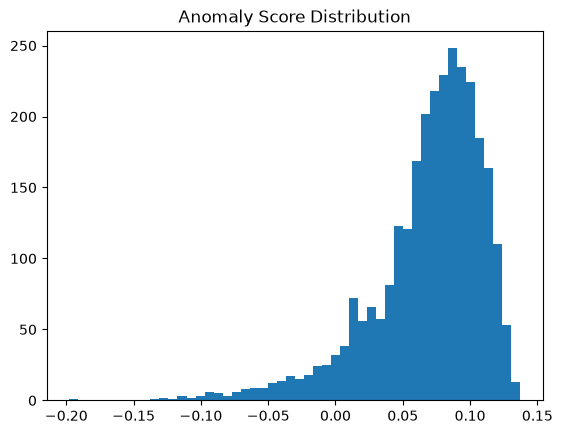

In [44]:
import matplotlib.pyplot as plt

plt.hist(df['anomaly_score'], bins=50)
plt.title("Anomaly Score Distribution")
plt.show()

In [45]:
anomalies = df[df['predicted_anomaly'] == 1]

anomalies.sort_values(by='anomaly_score').head(10)

,PoliceStationID,year_month,total_cases,heinous_ratio,undetected_ratio,false_case_ratio,avg_reporting_lag_days,pct_night_incidents,crime_head_diversity,case_count_zscore_vs_history,arrest_rate,is_anomaly,predicted_anomaly,anomaly_score
1821,38,2024-10-01,300,0.2392,0.4411,0.1135,33.96,0.4975,2.3230,3.500,0.3090,1,1,-0.197776
2814,59,2023-07-01,300,0.2639,0.1098,0.0307,2.20,0.4995,2.6942,3.500,0.6365,1,1,-0.132065
291,7,2021-04-01,32,0.4479,0.9091,0.0458,3.12,0.2612,1.5753,-3.500,0.2000,1,1,-0.129634
2721,57,2023-10-01,286,0.4407,0.2610,0.5347,9.50,0.2596,1.4896,3.500,0.6253,1,1,-0.127455
735,16,2022-04-01,32,0.0550,0.3692,0.1303,33.07,0.2038,1.0272,-2.513,0.3446,1,1,-0.122797
6,1,2021-07-01,68,0.1365,0.4962,0.1031,30.72,0.2232,2.6520,1.481,0.4560,0,1,-0.116194
1103,23,2024-12-01,148,0.2199,0.2462,0.0535,2.40,0.8743,3.1245,2.494,0.4169,0,1,-0.114007
1810,38,2023-11-01,213,0.6000,0.3190,0.0897,5.52,0.4452,2.2554,2.536,0.3690,1,1,-0.112503
2682,56,2024-07-01,91,0.1691,0.8899,0.0801,6.83,0.8911,1.7799,-0.813,0.2000,1,1,-0.109891
2524,53,2023-05-01,13,0.3601,0.2239,0.5458,4.38,0.0926,1.0673,-3.384,0.6937,1,1,-0.104531


In [46]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

Precision: 0.3811881188118812
Recall: 0.3532110091743119
F1: 0.36666666666666664


# Fixes

In [47]:
for c in [0.03, 0.05, 0.07, 0.1, 0.15,0.01, 0.03, 0.05, 0.07,0.01, 0.03, 0.1, 0.08,0.03, 0.05, 0.07, 0.1, 0.15,0.01, 0.03, 0.05, 0.07,0.01, 0.03, 0.1, 0.08]:
    model = IsolationForest(contamination=c, random_state=42)
    model.fit(X_scaled)
    y_pred = model.predict(X_scaled)
    y_pred = [1 if x == -1 else 0 for x in y_pred]
    
    from sklearn.metrics import f1_score
    print(c, f1_score(y_true, y_pred))


0.03 0.28852459016393445
0.05 0.34806629834254144
0.07 0.36666666666666664
0.1 0.3675889328063241
0.15 0.39384615384615385
0.01 0.1214574898785425
0.03 0.28852459016393445
0.05 0.34806629834254144
0.07 0.36666666666666664
0.01 0.1214574898785425
0.03 0.28852459016393445
0.1 0.3675889328063241
0.08 0.36525612472160357
0.03 0.28852459016393445
0.05 0.34806629834254144
0.07 0.36666666666666664
0.1 0.3675889328063241
0.15 0.39384615384615385
0.01 0.1214574898785425
0.03 0.28852459016393445
0.05 0.34806629834254144
0.07 0.36666666666666664
0.01 0.1214574898785425
0.03 0.28852459016393445
0.1 0.3675889328063241
0.08 0.36525612472160357


In [48]:
drop_cols = ['crime_head_diversity', 'pct_night_incidents']

X_new = df_model.drop(columns=drop_cols)

from sklearn.preprocessing import StandardScaler
X_scaled = StandardScaler().fit_transform(X_new)

In [49]:
from sklearn.svm import OneClassSVM

model = OneClassSVM(nu=0.07)

In [50]:
from sklearn.neighbors import LocalOutlierFactor

model = LocalOutlierFactor(n_neighbors=20, contamination=0.07)

In [51]:
from sklearn.metrics import precision_score, recall_score, f1_score

print("Precision:", precision_score(y_true, y_pred))
print("Recall:", recall_score(y_true, y_pred))
print("F1:", f1_score(y_true, y_pred))

Precision: 0.354978354978355
Recall: 0.3761467889908257
F1: 0.36525612472160357


# Trying dl

In [52]:
import numpy as np
import tensorflow as tf
from tensorflow.keras import layers, models

input_dim = X_train.shape[1]

# Build Autoencoder
input_layer = layers.Input(shape=(input_dim,))
encoder = layers.Dense(32, activation="relu")(input_layer)
encoder = layers.Dense(16, activation="relu")(encoder)

decoder = layers.Dense(32, activation="relu")(encoder)
decoder = layers.Dense(input_dim, activation="linear")(decoder)

autoencoder = models.Model(inputs=input_layer, outputs=decoder)
autoencoder.compile(optimizer='adam', loss='mse')

# Train ONLY on normal data
X_train_normal = X_train[y_train == 0]

autoencoder.fit(
    X_train_normal, X_train_normal,
    epochs=30,
    batch_size=32,
    validation_split=0.1,
    verbose=1
)

Epoch 1/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - loss: 0.8380 - val_loss: 0.6190
Epoch 2/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5667 - val_loss: 0.3565
Epoch 3/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.3076 - val_loss: 0.1911
Epoch 4/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.1772 - val_loss: 0.1273
Epoch 5/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.1149 - val_loss: 0.0876
Epoch 6/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - loss: 0.0735 - val_loss: 0.0575
Epoch 7/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0482 - val_loss: 0.0413
Epoch 8/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0358 - val_loss: 0.0329
Epoch 9/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 0.0286 - val_loss: 0.0274
Epoch 10/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0240 - val_loss: 0.0243
Epoch 11/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 0.0208 - val_loss: 0.0212
Epoch 12/30
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.0187 - val_lo

In [54]:
for p in [85, 90, 92, 95, 97]:
    threshold = np.percentile(reconstruction_error, p)
    y_pred = (reconstruction_error > threshold).astype(int)
    
    from sklearn.metrics import f1_score
    print(p, f1_score(y_test, y_pred))

85 0.47619047619047616
90 0.5773195876288659
92 0.5411764705882353
95 0.5
97 0.2807017543859649


In [55]:
# Reconstruction
X_test_pred = autoencoder.predict(X_test)

# Error
reconstruction_error = np.mean((X_test - X_test_pred)**2, axis=1)

# Threshold (tune this!)
threshold = np.percentile(reconstruction_error, 90)

y_pred = (reconstruction_error > threshold).astype(int)

from sklearn.metrics import classification_report
print(classification_report(y_test, y_pred))

18/18 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 
              precision    recall  f1-score   support

           0       0.98      0.94      0.96       537
           1       0.48      0.72      0.58        39

    accuracy                           0.93       576
   macro avg       0.73      0.83      0.77       576
weighted avg       0.95      0.93      0.94       576

